# 01 – Exploratory Data Analysis
**House Prices – Advanced Regression Techniques | Central AI Assessment**

---

This notebook covers:
- Target variable distribution analysis
- Missing value profiling
- Numerical feature correlations and distributions
- Categorical feature impact on SalePrice
- Outlier detection

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# Paths
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (1460, 81)  |  Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 1. Target Variable – SalePrice

The competition metric is **RMSLE**, which means we should log-transform `SalePrice`
before training so that minimising standard RMSE is equivalent to minimising RMSLE.

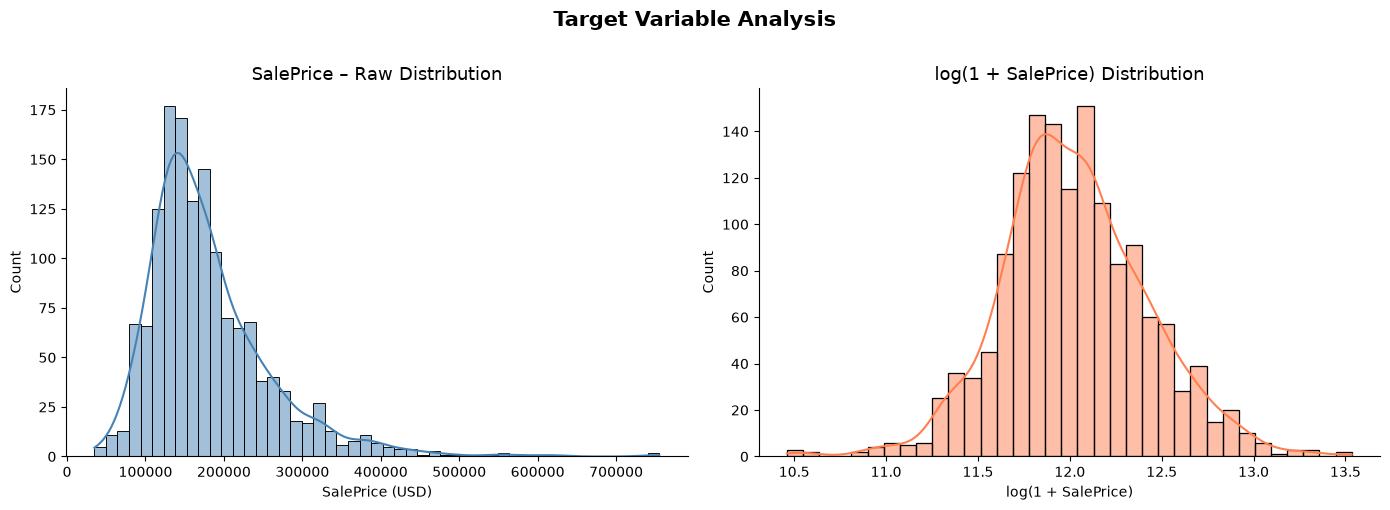

count      1,460
mean     180,921
std       79,443
min       34,900
25%      129,975
50%      163,000
75%      214,000
max      755,000
Name: SalePrice, dtype: str

Skewness raw   : 1.8809
Skewness log1p : 0.1212


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice – Raw Distribution', fontsize=13)
axes[0].set_xlabel('SalePrice (USD)')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('log(1 + SalePrice) Distribution', fontsize=13)
axes[1].set_xlabel('log(1 + SalePrice)')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(train['SalePrice'].describe().apply(lambda x: f'{x:,.0f}'))
print(f'\nSkewness raw   : {skew(train["SalePrice"]):.4f}')
print(f'Skewness log1p : {skew(np.log1p(train["SalePrice"])):.4f}')

## 2. Missing Value Analysis

Train: 19 features with missing values
              Count  Pct (%)
PoolQC         1453    99.52
MiscFeature    1406    96.30
Alley          1369    93.77
Fence          1179    80.75
MasVnrType      872    59.73
FireplaceQu     690    47.26
LotFrontage     259    17.74
GarageType       81     5.55
GarageYrBlt      81     5.55
GarageFinish     81     5.55
GarageQual       81     5.55
GarageCond       81     5.55
BsmtExposure     38     2.60
BsmtFinType2     38     2.60
BsmtQual         37     2.53
BsmtCond         37     2.53
BsmtFinType1     37     2.53
MasVnrArea        8     0.55
Electrical        1     0.07


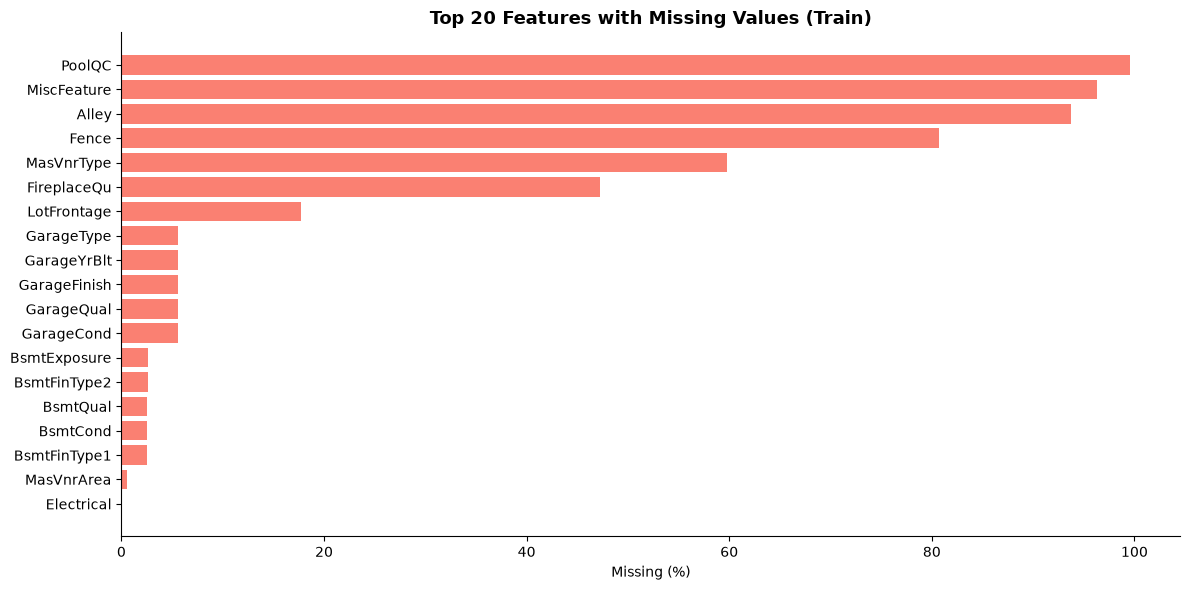

In [3]:
def missing_summary(df, label='Train'):
    miss     = df.isnull().sum()
    miss     = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    return pd.DataFrame({'Count': miss, 'Pct (%)': miss_pct})

train_miss = missing_summary(train, 'Train')
test_miss  = missing_summary(test,  'Test')

print(f'Train: {len(train_miss)} features with missing values')
print(train_miss.head(20).to_string())

top20 = train_miss.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20.index[::-1], top20['Pct (%)'][::-1], color='salmon')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 20 Features with Missing Values (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numerical Features – Correlations

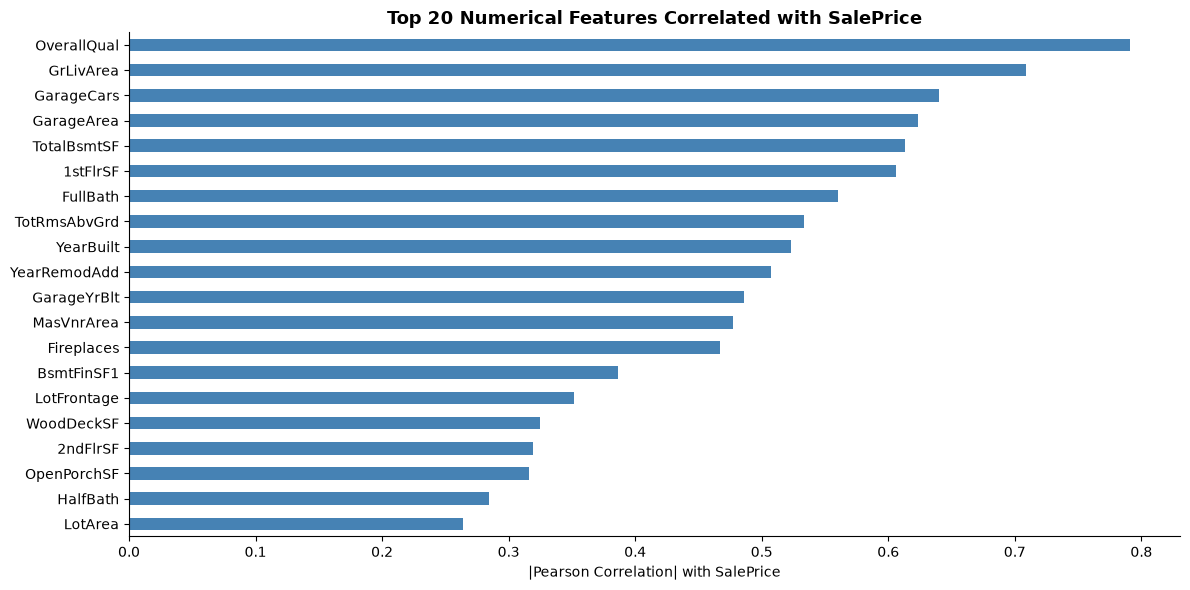

Top 10 correlated features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [4]:
num_feats = train.select_dtypes(include=[np.number]).columns.drop('Id')
corr = train[num_feats].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

top20_corr = corr.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top20_corr[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('|Pearson Correlation| with SalePrice')
ax.set_title('Top 20 Numerical Features Correlated with SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 correlated features:')
print(top20_corr.head(10).to_string())

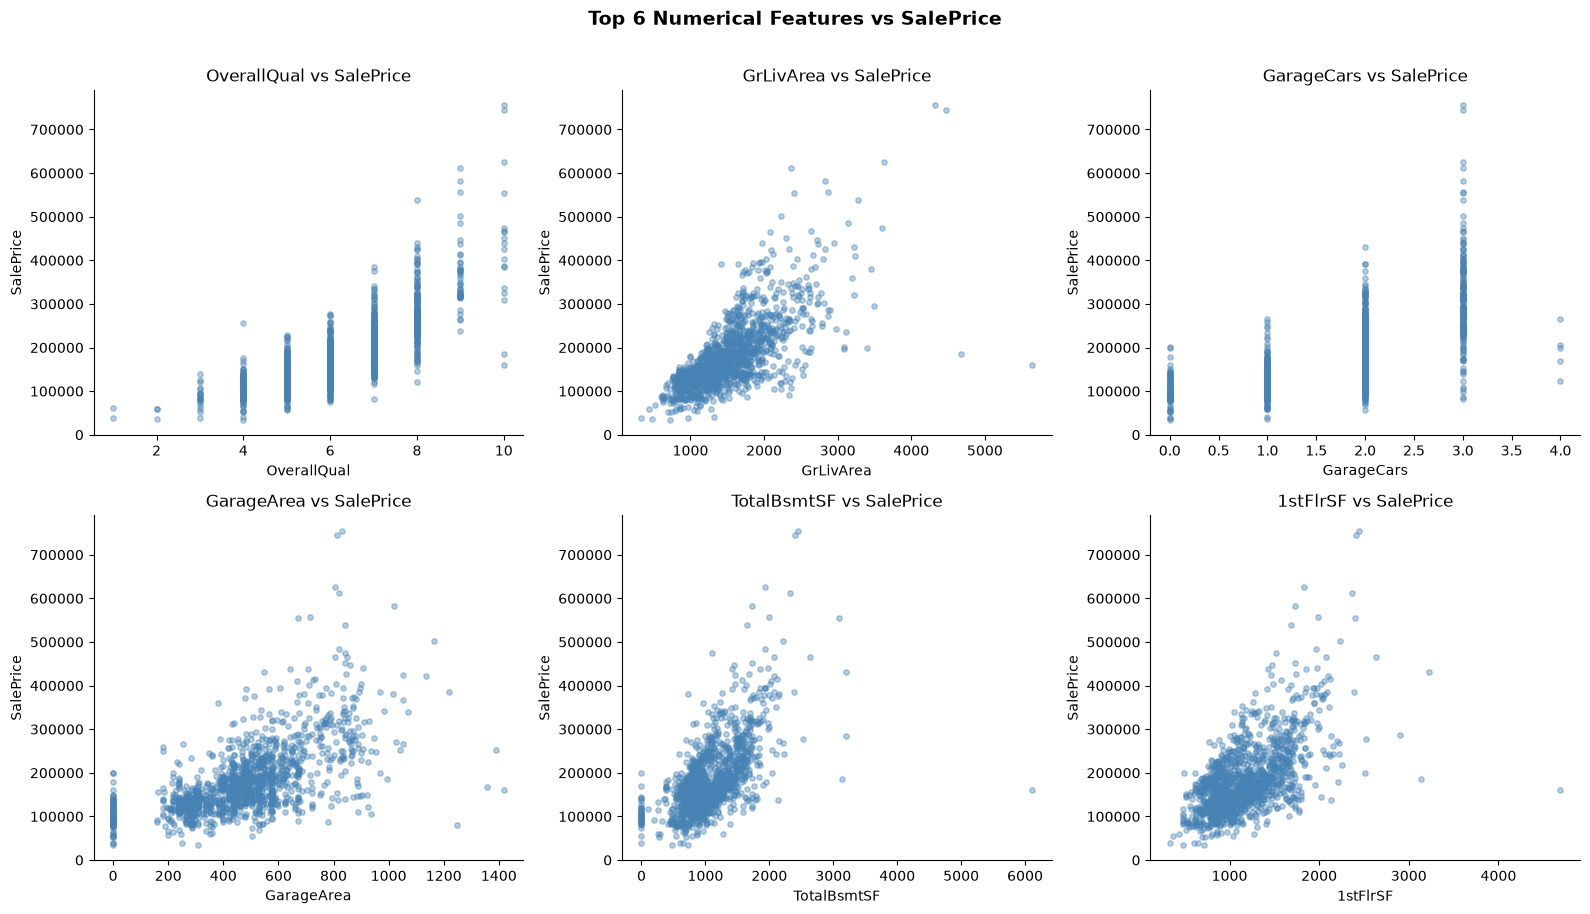

In [5]:
top6 = top20_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), top6):
    ax.scatter(train[col], train['SalePrice'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col} vs SalePrice')
plt.suptitle('Top 6 Numerical Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'scatter_top6.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Categorical Features

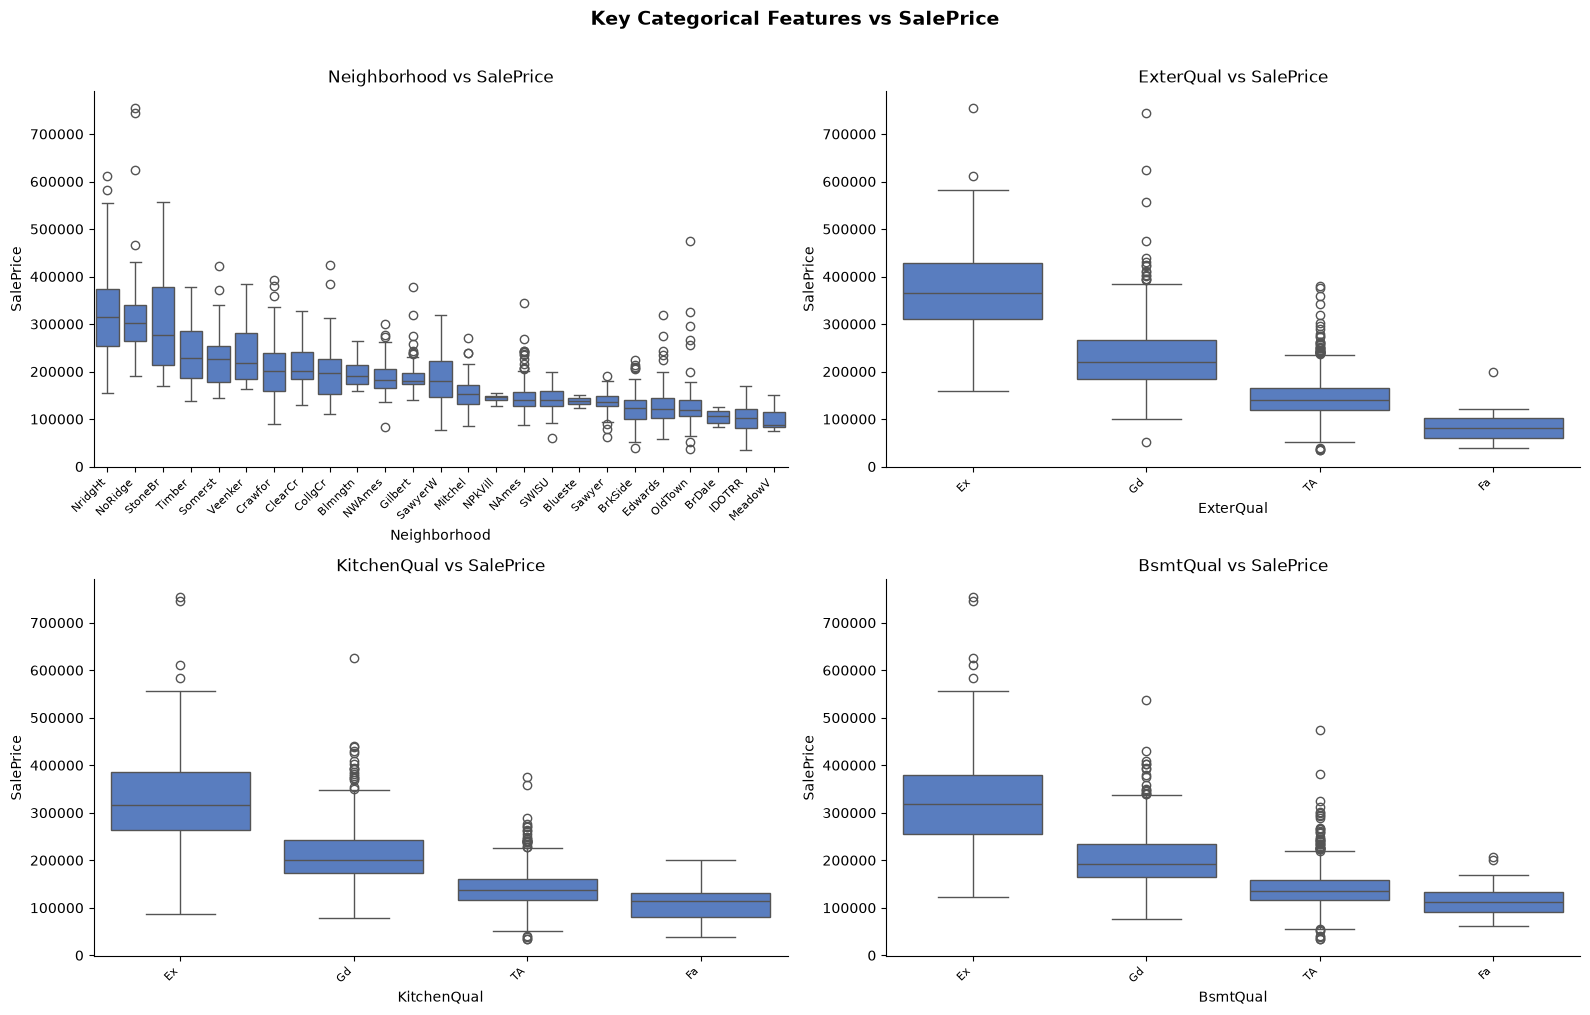

In [6]:
top_cats = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), top_cats):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='SalePrice', order=order, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{col} vs SalePrice')
plt.suptitle('Key Categorical Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Outlier Detection

The dataset author (Dean De Cock) recommends removing two outliers:
homes with large living area but very low sale price (likely partial/abnormal sales).

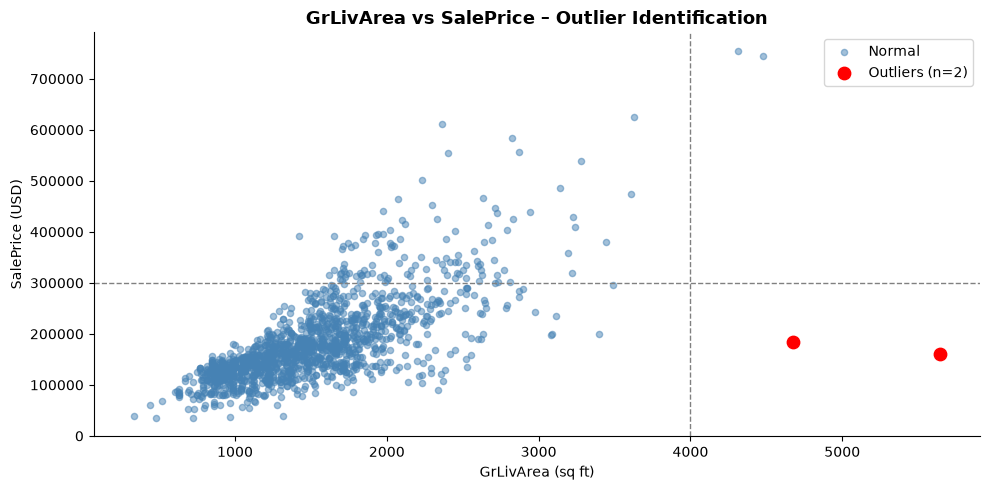

Outlier records:
  Id  GrLivArea  SalePrice
 524       4676     184750
1299       5642     160000


In [7]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, s=20, color='steelblue', label='Normal')
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           color='red', s=80, zorder=5, label=f'Outliers (n={len(outliers)})')
ax.axvline(4000, color='gray', linestyle='--', linewidth=1)
ax.axhline(300_000, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('GrLivArea (sq ft)')
ax.set_ylabel('SalePrice (USD)')
ax.set_title('GrLivArea vs SalePrice – Outlier Identification', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print('Outlier records:')
print(outliers[['Id', 'GrLivArea', 'SalePrice']].to_string(index=False))

## EDA Summary

| Observation | Action |
|-------------|--------|
| SalePrice is right-skewed | Log-transform the target before modelling |
| ~19 features have missing values; PoolQC (99%), Alley (93%), etc. | Impute with 'None' (structural absence) or neighbourhood median |
| OverallQual, GrLivArea, GarageCars are top predictors | Keep; create interaction features |
| Neighborhood has strong price spread | Include; consider target encoding |
| 2 extreme outliers (large area, low price) | Remove before training |